# The Resampled Frontier \U0001F3B2
### Optimise a thousand times, average the answers, hope the noise cancels

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

Feed a mean-variance optimiser real estimates and it will hand you a portfolio with three
positions and a straight face. Michaud's answer: bootstrap the data, optimise on each sample,
and average. The portfolios come out beautifully diversified. This notebook asks whether the
averaging is the reason.

> \U0001F4D3 **This is the plain-language layer.** The optimisers, the weight geometry and the
> known-truth experiment are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does the plain optimiser really produce absurd portfolios? | Yes — a handful of positions and enormous weights, every rebalance. |
| Does resampling fix that? | Completely. The averaged portfolio holds nearly everything. |
| Is the averaging the reason? | Largely not. A default shrinkage, computed once, lands in almost the same place. |
| Is it worth a thousand optimisations? | Only if you have no shrinkage code — and shrinkage is nine lines. |

## 1 · The claim

> *"The efficient frontier is an illusion of precision. Resample it, average the portfolios,
> and you get something you can actually hold."*

The first sentence is unarguable. The second is a solution, and it competes with other
solutions.

In [2]:
from resampled import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {"multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000],
          "sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500]}
print(f"as-of {data.AS_OF}")
for tag, cols in panels.items():
    print(f"  {tag:12s} {len(cols):2d} assets, "
          f"{len(rets[cols].dropna(how='any')):,} common sessions")

as-of 2026-06-30
  multi-asset  10 assets, 4,835 common sessions
  sectors      11 assets, 2,017 common sessions


## 2 · What the plain optimiser does

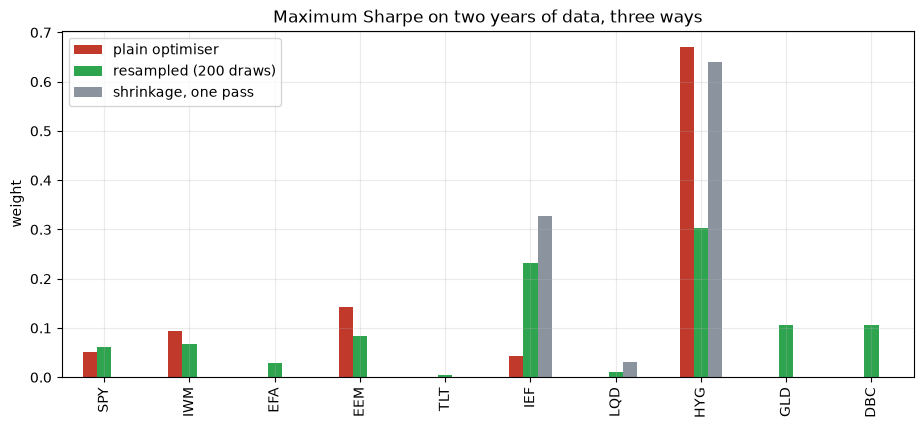

             plain  resampled  shrunk
max_weight  0.6700     0.3030  0.6410
effective_n 2.0740     5.4470  1.9250
n_held      5.0000    10.0000  3.0000


In [3]:
cols = panels["multi-asset"]
sub = rets[cols].dropna(how="any")
X = sub.iloc[-504:].to_numpy()
w_plain = st.plain_weights(X, "max_sharpe")
w_res = st.resampled_weights(X, "max_sharpe", n_resamples=200, seed=978)
w_shr = st.shrunk_weights(X, "max_sharpe")
W = pd.DataFrame({"plain optimiser": w_plain, "resampled (200 draws)": w_res,
                  "shrinkage, one pass": w_shr}, index=cols)
fig, ax = plt.subplots(figsize=(11, 4.5))
W.plot.bar(ax=ax, color=["#c0392b", "#2ea44f", "#8b949e"])
ax.set_ylabel("weight"); ax.legend(title="")
ax.set_title("Maximum Sharpe on two years of data, three ways")
plt.show()
print(pd.DataFrame({k: st.concentration(v) for k, v in
                    {"plain": w_plain, "resampled": w_res, "shrunk": w_shr}.items()}).round(3).to_string())

> \U0001F52C **For the quants.** Look at the green and grey bars. Those are two completely
> different procedures — a Monte Carlo average of 200 optimisations, and a single closed-form
> shrinkage — and they are hard to tell apart.

## 3 · Out of sample

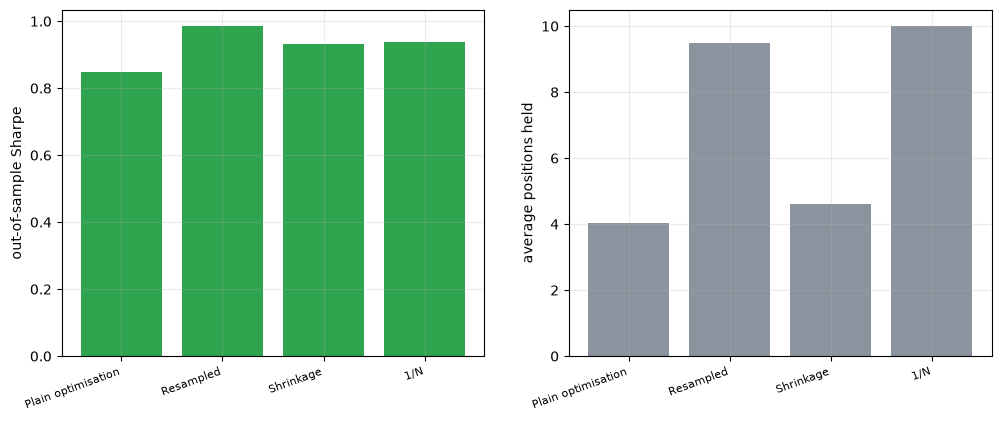

,mean_ret,realised_vol,sharpe,turnover,max_weight,n_held
method,,,,,,
plain,0.0620,0.0730,0.8490,0.5320,0.5380,4.0290
resampled,0.0680,0.0690,0.9850,0.3980,0.3660,9.4850
shrunk,0.0590,0.0630,0.9310,0.4800,0.5340,4.6180
equal,0.0830,0.0880,0.9390,0.0150,0.1000,10.0000


In [4]:
wf = st.walk_forward(sub, "max_sharpe", window=504, step=63, cost_bps=5.0,
                     n_resamples=40)
s = st.summarise(wf)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([st.METHOD_LABEL[m].split(" (")[0] for m in s.index], s["sharpe"], color="#2ea44f")
axes[0].set_ylabel("out-of-sample Sharpe")
axes[1].bar([st.METHOD_LABEL[m].split(" (")[0] for m in s.index], s["n_held"], color="#8b949e")
axes[1].set_ylabel("average positions held")
for a in axes:
    plt.setp(a.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
s[["mean_ret", "realised_vol", "sharpe", "turnover", "max_weight", "n_held"]].round(3)

## 4 · The comparison that settles it

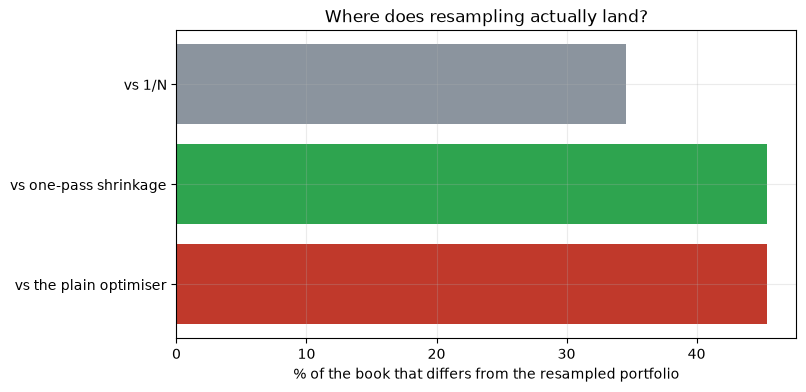

vs the plain optimiser   0.4539
vs one-pass shrinkage    0.4541
vs 1/N                   0.3455
dtype: float64

In [5]:
gaps = pd.Series({
    "vs the plain optimiser": st.weight_distance(w_res, w_plain),
    "vs one-pass shrinkage": st.weight_distance(w_res, w_shr),
    "vs 1/N": st.weight_distance(w_res, np.full(len(cols), 1 / len(cols))),
})
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(gaps.index, gaps.values * 100, color=["#c0392b", "#2ea44f", "#8b949e"])
ax.set_xlabel("% of the book that differs from the resampled portfolio")
ax.set_title("Where does resampling actually land?")
plt.show()
gaps.round(4)

## 5 · The verdict

**Signal: Real.** Averaging a thousand optimisations does produce a different portfolio: it differs from the single-shot answer by **45%** of the book, holds **10** positions against 4, and caps its largest weight at 37% against 54%. Against a **known** true covariance and mean it also helps: the utility gap falls from 0.0183 to **0.0150** (0.0169 for shrinkage, 0.0234 for 1/N). The averaging is doing something real — the question is whether it is doing anything *distinctive*.

**Usefulness: Fragile.** Out of sample on the 10-sleeve panel, resampling returned **+6.79%/yr** at 6.91% volatility (Sharpe +0.98) against +6.16% / +0.85 for the plain optimiser (paired *t* on the return difference +0.97) and +5.90% / +0.93 for plain shrinkage (*t* = **+1.07**). Its weights sit **45%** from the shrunk portfolio's and 45% from the plain one — closer to the cheap fix than to the thing it is fixing, which is the whole story. It also costs 60 optimisations per rebalance.

## 6 · Going further \U0001F6AA

- **Bayesian portfolio choice** (Harvey, Liechty & Liechty 2008) does what resampling gestures
  at, properly, and dominates it in their experiment.
- **Turnover-aware resampling**: the smoother weights are worth much more when trading is
  expensive than this study's 5 bps credits them for.
- **Resampling *with* shrinkage** — the two are not exclusive, and nobody seems to have tried
  stacking them.